In [10]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.stem.porter import PorterStemmer

# 1. Import Dataset from Kaggle

os.system('kaggle datasets download -d elvis23/mental-health-conversational-data')
os.system('unzip mental-health-conversational-data.zip')

# Load the JSON data
with open('intents.json', 'r') as f:
    intents = json.load(f)

stemmer = PorterStemmer()
nltk.download('punkt')

def tokenize(sentence):
    return nltk.word_tokenize(sentence)

def stem(word):
    return stemmer.stem(word.lower())

def bag_of_words(tokenized_sentence, words):
    sentence_words = [stem(word) for word in tokenized_sentence]
    bag = np.zeros(len(words), dtype=np.float32)
    for idx, w in enumerate(words):
        if w in sentence_words:
            bag[idx] = 1
    return bag

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chakr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
all_words = []
tags = []
xy = []

for intent in intents['intents']:
    tag = intent['tag']
    tags.append(tag)
    for pattern in intent['patterns']:
        w = tokenize(pattern)
        all_words.extend(w)
        xy.append((w, tag))

all_words = sorted(set([stem(w) for w in all_words if w not in ['?', '!', '.', ',']]))
tags = sorted(set(tags))

X = []
y = []
for (pattern_sentence, tag) in xy:
    bag = bag_of_words(pattern_sentence, all_words)
    X.append(bag)
    label = tags.index(tag)
    y.append(label)

X = np.array(X)
y = np.array(y)

# Simulate 3 Clients by splitting the data
client_data = []
indices = np.random.permutation(len(X))
split_idx = len(X) // 3

for i in range(3):
    start, end = i * split_idx, (i + 1) * split_idx
    client_X = torch.from_numpy(X[indices[start:end]])
    client_y = torch.from_numpy(y[indices[start:end]]).long()
    client_data.append((client_X, client_y))

In [3]:
class ChatModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ChatModel, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        out = self.relu(self.l1(x))
        out = self.relu(self.l2(out))
        return self.l3(out)

input_size = len(all_words)
hidden_size = 8
num_classes = len(tags)

In [14]:
def train_local(model, data, epochs=10):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    inputs, labels = data
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    return model.state_dict()

def aggregate_weights(global_model, client_weights):
    global_dict = global_model.state_dict()
    for k in global_dict.keys():
        global_dict[k] = torch.stack([client_weights[i][k] for i in range(len(client_weights))], 0).mean(0)
    global_model.load_state_dict(global_dict)

# Global Server Initialization
global_model = ChatModel(input_size, hidden_size, num_classes)
num_rounds = 50

print("Starting Federated Training...")
for round in range(num_rounds):
    client_weights = []
    for i in range(3):
        # Create a local copy of the global model
        local_model = ChatModel(input_size, hidden_size, num_classes)
        local_model.load_state_dict(global_model.state_dict())
        
        # Train locally
        weights = train_local(local_model, client_data[i],epochs=20)
        client_weights.append(weights)
    
    # Update Global Model
    aggregate_weights(global_model, client_weights)
    print(f"Round {round+1}/{num_rounds} complete.")

torch.save(global_model.state_dict(), "federated_chatbot.pth")

Starting Federated Training...
Round 1/50 complete.
Round 2/50 complete.
Round 3/50 complete.
Round 4/50 complete.
Round 5/50 complete.
Round 6/50 complete.
Round 7/50 complete.
Round 8/50 complete.
Round 9/50 complete.
Round 10/50 complete.
Round 11/50 complete.
Round 12/50 complete.
Round 13/50 complete.
Round 14/50 complete.
Round 15/50 complete.
Round 16/50 complete.
Round 17/50 complete.
Round 18/50 complete.
Round 19/50 complete.
Round 20/50 complete.
Round 21/50 complete.
Round 22/50 complete.
Round 23/50 complete.
Round 24/50 complete.
Round 25/50 complete.
Round 26/50 complete.
Round 27/50 complete.
Round 28/50 complete.
Round 29/50 complete.
Round 30/50 complete.
Round 31/50 complete.
Round 32/50 complete.
Round 33/50 complete.
Round 34/50 complete.
Round 35/50 complete.
Round 36/50 complete.
Round 37/50 complete.
Round 38/50 complete.
Round 39/50 complete.
Round 40/50 complete.
Round 41/50 complete.
Round 42/50 complete.
Round 43/50 complete.
Round 44/50 complete.
Round 45/5

In [ ]:
global_model.eval()
bot_name = "Confused Box"


def get_response(msg):
    sentence = tokenize(msg)
    X = bag_of_words(sentence, all_words)
    X = torch.from_numpy(X.reshape(1, X.shape[0]))
    
    output = global_model(X)
    _, predicted = torch.max(output, dim=1)
    tag = tags[predicted.item()]
    
    probs = torch.softmax(output, dim=1)
    prob = probs[0][predicted.item()]
    
    if prob.item() > 0.30:
        for intent in intents['intents']:
            if tag == intent['tag']:
                return np.random.choice(intent['responses'])
    return "I'm not sure I understand. Could you tell me more?"

# Example Chat
print("Confused Box is online! (type 'quit' to exit)")
while True:
    sentence = input("You: ")
    if sentence == "quit": break
    print(f"{bot_name}: {get_response(sentence)}")

Confused Box is online! (type 'quit' to exit)


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Split into Train and Test (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-partition the X_train for Federated Clients (3 clients)
client_data = []
indices = np.random.permutation(len(X_train))
split_idx = len(X_train) // 3

for i in range(3):
    start, end = i * split_idx, (i + 1) * split_idx
    c_X = torch.from_numpy(X_train[indices[start:end]]).float()
    c_y = torch.from_numpy(y_train[indices[start:end]]).long()
    client_data.append((c_X, c_y))

# Prepare Global Test Data
test_X = torch.from_numpy(X_test).float()
test_y = torch.from_numpy(y_test).long()

In [7]:
print(f"Input Data Shape: {X_train.shape}") # Should not be 0
print(f"Unique Labels in Train: {len(np.unique(y_train))}") # Should match your intents

Input Data Shape: (185, 279)
Unique Labels in Train: 73


In [12]:
def evaluate_global(model, round_num):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        outputs = model(test_X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(test_y.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    
    # ADD THIS LINE: Calculate F1
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    
    print(f"Round {round_num} | Acc: {acc:.2f} | Prec: {prec:.2f} | Rec: {rec:.2f} | F1: {f1:.2f}")
    return acc, prec, rec, f1  # Now returning 4 values

In [13]:
# Initialize history with the 'f1' key
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
history = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'loss': []}

for round in range(num_rounds):
    client_weights = []
    for i in range(3):
        local_model = ChatModel(input_size, hidden_size, num_classes)
        local_model.load_state_dict(global_model.state_dict())
        weights = train_local(local_model, client_data[i], epochs=50)
        client_weights.append(weights)
    
    aggregate_weights(global_model, client_weights)
    
    # UNPACK 4 VALUES NOW:
    acc, prec, rec, f1 = evaluate_global(global_model, round + 1)
    
    history['accuracy'].append(acc)
    history['precision'].append(prec)
    history['recall'].append(rec)
    history['f1'].append(f1) # This stops the KeyError

Round 1 | Acc: 0.40 | Prec: 0.33 | Rec: 0.40 | F1: 0.34
Round 2 | Acc: 0.40 | Prec: 0.33 | Rec: 0.40 | F1: 0.35
Round 3 | Acc: 0.40 | Prec: 0.33 | Rec: 0.40 | F1: 0.35
Round 4 | Acc: 0.40 | Prec: 0.33 | Rec: 0.40 | F1: 0.35
Round 5 | Acc: 0.43 | Prec: 0.35 | Rec: 0.43 | F1: 0.37
Round 6 | Acc: 0.40 | Prec: 0.32 | Rec: 0.40 | F1: 0.34
Round 7 | Acc: 0.43 | Prec: 0.34 | Rec: 0.43 | F1: 0.36
Round 8 | Acc: 0.43 | Prec: 0.34 | Rec: 0.43 | F1: 0.36
Round 9 | Acc: 0.43 | Prec: 0.35 | Rec: 0.43 | F1: 0.36
Round 10 | Acc: 0.45 | Prec: 0.36 | Rec: 0.45 | F1: 0.39
Round 11 | Acc: 0.43 | Prec: 0.34 | Rec: 0.43 | F1: 0.37
Round 12 | Acc: 0.45 | Prec: 0.38 | Rec: 0.45 | F1: 0.40
Round 13 | Acc: 0.45 | Prec: 0.37 | Rec: 0.45 | F1: 0.39
Round 14 | Acc: 0.43 | Prec: 0.35 | Rec: 0.43 | F1: 0.37
Round 15 | Acc: 0.43 | Prec: 0.35 | Rec: 0.43 | F1: 0.37
Round 16 | Acc: 0.43 | Prec: 0.36 | Rec: 0.43 | F1: 0.38
Round 17 | Acc: 0.43 | Prec: 0.36 | Rec: 0.43 | F1: 0.38
Round 18 | Acc: 0.43 | Prec: 0.35 | Rec:

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

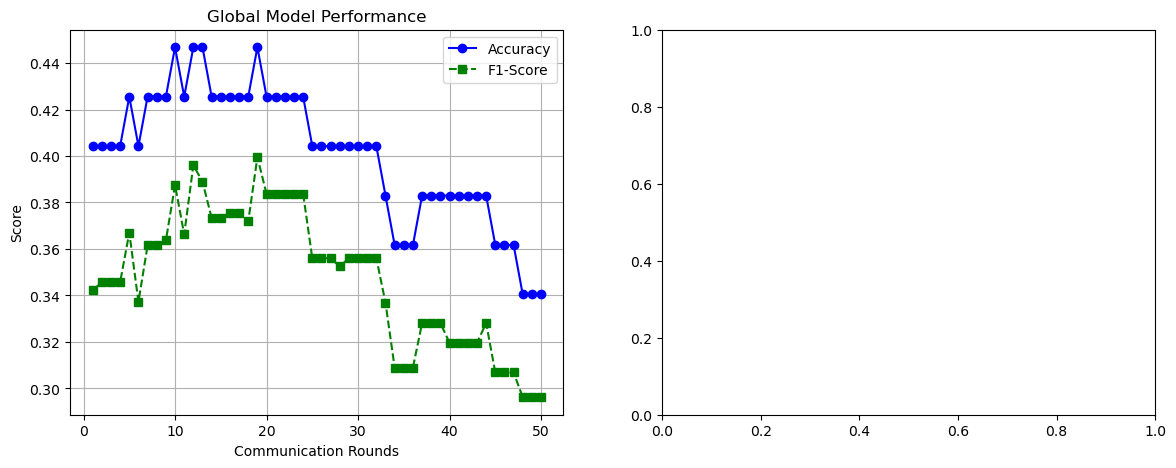

In [14]:
def plot_metrics(history):
    rounds = range(1, len(history['accuracy']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Graph 1: Accuracy & F1-Score
    plt.subplot(1, 2, 1)
    plt.plot(rounds, history['accuracy'], 'o-', label='Accuracy', color='blue')
    plt.plot(rounds, history['f1'], 's--', label='F1-Score', color='green')
    plt.title('Global Model Performance')
    plt.xlabel('Communication Rounds')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    
    # Graph 2: Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(rounds, history['loss'], 'r^-', label='Global Loss')
    plt.title('Global Model Convergence')
    plt.xlabel('Communication Rounds')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Graph 3: Precision vs Recall Comparison
    plt.figure(figsize=(7, 5))
    plt.bar(['Precision', 'Recall'], [history['precision'][-1], history['recall'][-1]], color=['teal', 'orange'])
    plt.ylim(0, 1)
    plt.title('Final Round: Precision vs Recall')
    plt.ylabel('Score')
    plt.show()

plot_metrics(history)